## Comparative analysis of results in Bologna:

### Mean Radiant Temperature predicted from High resolution data and open Global datasets

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.ticker as mticker
from rasterio.transform import rowcol

In [2]:
# inputs
mrt_predicted_hr_data = '../../datos-notebooks/3.HR-data-bologna/MRT-prediction/MRT_1m_condistance.tif'
mrt_predicted_global_data_2 = '../../datos-notebooks/2.global-data-bologna/MRT-prediction/MRT_fromglobal_1m.tif'

# outputs
output_folder = '../../datos-notebooks/4.comparative-analysis/'
os.makedirs(output_folder, exist_ok=True)
out_diff      = os.path.join(output_folder, 'MRT_difference_bologna.tif')
out_fig_maps  = os.path.join(output_folder, 'mapas_mrt_comparacion.png')
out_fig_diff  = os.path.join(output_folder, 'diff_mrt_hr_global.png')
out_fig_thr   = os.path.join(output_folder, 'umbral_mrt.png')

### differences between predictions 

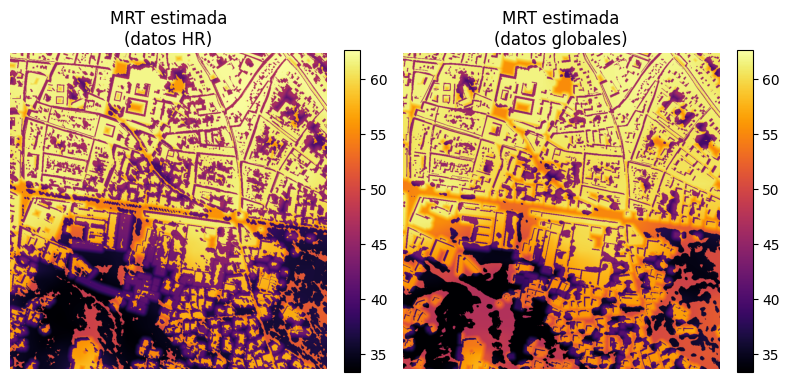

In [ ]:
with  rasterio.open(mrt_predicted_hr_data) as hr, rasterio.open(mrt_predicted_global_data_2) as glob:
    xmin, ymin, xmax, ymax = hr.bounds
    hr_data = hr.read(1).astype("float32")  
    glob_data = glob.read(1).astype("float32")
    
fig, axes = plt.subplots(1, 2, figsize=(8, 4))



# HR predicted
im1 = axes[0].imshow(hr_data, cmap="inferno", vmin=np.nanmin(hr_data), vmax=np.nanmax(hr_data))
axes[0].set_title("MRT estimada\n(datos HR)")
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Global predicted
im2 = axes[1].imshow(glob_data, cmap="inferno", vmin=np.nanmin(hr_data), vmax=np.nanmax(hr_data))
axes[1].set_title("MRT estimada\n(datos globales)")
plt.colorbar(im2, ax=axes[1], fraction=0.046)



for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#window


# Define the window in geographic coordinates (adjust these values)
win_xmin, win_ymin, win_xmax, win_ymax = 686000, 4928000, 687000, 4929000

with rasterio.open(mrt_predicted_hr_data) as hr, rasterio.open(mrt_predicted_global_data_2) as glob:
    transform = hr.transform
    
    # Convert geographic coordinates to pixel indices
    row_min, col_min = rowcol(transform, win_xmin, win_ymax)  # upper-left corner
    row_max, col_max = rowcol(transform, win_xmax, win_ymin)  # lower-right corner
    
    hr_data   = hr.read(1).astype("float32")[row_min:row_max, col_min:col_max]
    glob_data = glob.read(1).astype("float32")[row_min:row_max, col_min:col_max]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

im1 = axes[0].imshow(hr_data, cmap="inferno", vmin=np.nanmin(hr_data), vmax=np.nanmax(hr_data))
axes[0].set_title("MRT estimada\n(datos HR)")
plt.colorbar(im1, ax=axes[0], fraction=0.046)

im2 = axes[1].imshow(glob_data, cmap="inferno", vmin=np.nanmin(hr_data), vmax=np.nanmax(hr_data))
axes[1].set_title("MRT estimada\n(datos globales)")
plt.colorbar(im2, ax=axes[1], fraction=0.046)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

#### model trained with HR data applied with HR data - model trained with global applied with global datasets

In [7]:
os.makedirs(os.path.dirname(out_diff), exist_ok=True)

with rasterio.open(mrt_predicted_hr_data) as src1, \
     rasterio.open(mrt_predicted_global_data_2) as src2:

    # determine common intersection
    h = min(src1.height, src2.height)
    w = min(src1.width, src2.width)

    # read only that intersection (light)
    r1 = src1.read(1, window=((0, h), (0, w))).astype("float32")
    r2 = src2.read(1, window=((0, h), (0, w))).astype("float32")

    nodata = src1.nodata

    # build mask in HR intersection grid
    mask = np.isfinite(r1)
    if nodata is not None:
        mask &= (r1 != nodata)

    diff = r1 - r2
    diff[~mask] = nodata

    profile = src1.profile
    profile.update(dtype="float32", height=h, width=w, transform=src1.transform)

    with rasterio.open(out_diff, "w", **profile) as dst:
        dst.write(diff.astype("float32"), 1)

    print("Saved in:", out_diff)

Saved in: ../../datos-notebooks/4.comparative-analysis/MRT_difference_bologna.tif


In [4]:
# Quantify raster differences
with rasterio.open(out_diff) as srcd:
    diff = srcd.read(1).astype("float32")
    nodata = srcd.nodata

# Build valid mask
mask = np.isfinite(diff)
if nodata is not None:
    mask &= (diff != nodata)

d = diff[mask]

# Basic stats 
print(f"Mean diff: {np.mean(d):.3f}")
print(f"Median diff: {np.median(d):.3f}")
print(f"Std diff: {np.std(d):.3f}")

# Error-like metrics 
mae = float(np.mean(np.abs(d)))
rmse = float(np.sqrt(np.mean(d**2)))
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

Mean diff: -1.215
Median diff: 0.639
Std diff: 7.707
MAE: 4.984
RMSE: 7.802


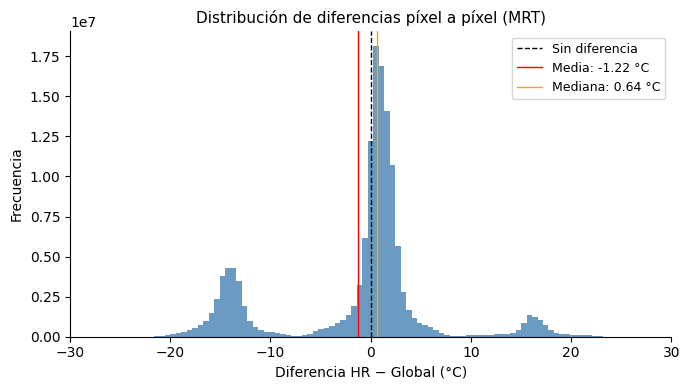

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(d, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(0, color='black', linewidth=1, linestyle='--', label='Sin diferencia')
ax.axvline(np.mean(d), color='red', linewidth=1, linestyle='-', label=f'Media: {np.mean(d):.2f} °C')
ax.axvline(np.median(d), color='orange', linewidth=1, linestyle='-', label=f'Mediana: {np.median(d):.2f} °C')

ax.set_xlabel('Diferencia HR − Global (°C)', fontsize=10)
ax.set_ylabel('Frecuencia', fontsize=10)
ax.set_title('Distribución de diferencias píxel a píxel (MRT)', fontsize=11)
ax.set_xlim(-30, 30)  # adjust according to your data
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'hist_diff_mrt.png'), dpi=200, bbox_inches='tight')
plt.show()

In [9]:
# Plot result 
with rasterio.open(out_diff) as src:
    diff = src.read(1).astype("float32")
    xmin, ymin, xmax, ymax = src.bounds


# Difference map
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(diff, cmap='RdBu_r')
ax.axis('off')
ax.set_title('Diferencia entre predicciones MRT (HR − Global)', fontsize=11)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)
cb.set_label('Diferencia (°C)', fontsize=9)
cb.ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(out_fig_diff, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', out_fig_diff)

MemoryError: Unable to allocate 7.27 GiB for an array with shape (15071, 16183, 4) and data type float64

Error in callback <function _draw_all_if_interactive at 0x0000020E62ED3C40> (for post_execute), with arguments args (),kwargs {}:


MemoryError: Unable to allocate 7.27 GiB for an array with shape (15071, 16183, 4) and data type float64

MemoryError: Unable to allocate 233. MiB for an array with shape (15071, 16183) and data type bool

<Figure size 700x700 with 2 Axes>

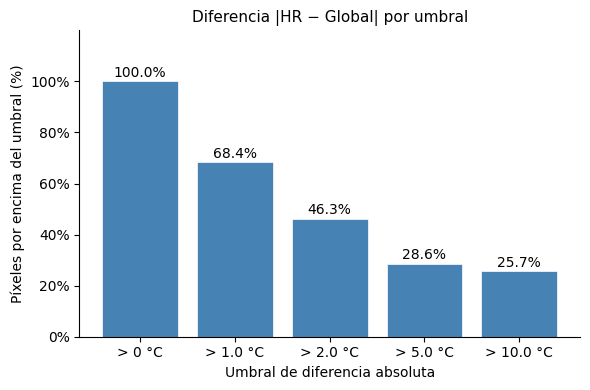

Guardado: ../../datos-notebooks/4.comparative-analysis/umbral_mrt.png


In [5]:
thresholds = [0,1.0, 2.0, 5.0, 10.0]
fractions  = [float(np.mean(np.abs(d) > thr) * 100) for thr in thresholds]
labels     = [f'> {t} °C' for t in thresholds]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, fractions, color='steelblue', edgecolor='white', linewidth=0.5)

# Values above each bar
for bar, val in zip(bars, fractions):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_xlabel('Umbral de diferencia absoluta', fontsize=10)
ax.set_ylabel('Píxeles por encima del umbral (%)', fontsize=10)
ax.set_title('Diferencia |HR − Global| por umbral', fontsize=11)
ax.set_ylim(0, max(fractions) * 1.2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(out_fig_thr, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', out_fig_thr)